
# Dominance Analysis Notebook for Arya Phones

Bu notebook, **Supplier** ve **User** sheet'lerini okuyup aşağıdaki analizleri yapar:

1. **Pareto dominance** (supplier kriterleri üzerinden)
2. **Pointwise utility dominance** (user ağırlıklarıyla)
3. **First-order stochastic dominance (FOSD)** (utility dağılımları üzerinden)
4. Görselleştirmeler:
   - tedarikçi profil heatmap'i
   - dominance matrix'leri
   - dominance sayıları bar chart'ı
   - utility dağılımı boxplot'u
   - seçili supplier çiftleri için ampirik CDF

## Nasıl okunmalı?

- **Pareto dominance**: Bir supplier başka bir supplier'dan hiçbir kriterde kötü değilse ve en az bir kriterde daha iyiyse domine eder.
- **Pointwise utility dominance**: Her user için utility'si en az diğer supplier kadar yüksekse domine eder.
- **FOSD**: Utility dağılımı anlamında her eşikte en az diğer supplier kadar iyiyse domine eder.

## Önemli nokta: yön seçimi

Notebook iki farklı yorum destekler:

- **`MODE = "business"`**  
  Risk / cost / defect / compliance değişkenleri **küçük daha iyi**,  
  strategic importance / improvement potential **büyük daha iyi** kabul edilir.

- **`MODE = "current_code"`**  
  Ham supplier skorları user ağırlıklarıyla doğrudan çarpılır.  
  Bu, mevcut kod davranışına daha yakın bir referans analizdir.

Varsayılan olarak `business` seçili geliyor.


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

FILE_PATH = "Arya_Phones_Supplier_Selection.xlsx"
SUPPLIER_SHEET = "Supplier"
USER_SHEET = "User"

# "business" veya "current_code"
MODE = "current_code"

supplier_df = pd.read_excel(FILE_PATH, sheet_name=SUPPLIER_SHEET)
user_df = pd.read_excel(FILE_PATH, sheet_name=USER_SHEET)

display(supplier_df.head())
display(user_df.head())
print("Supplier rows:", len(supplier_df), "| User rows:", len(user_df))


,Supplier,Environmental Risk,Social Risk,Cost Score,Strategic Importance,Improvement Potential,Child Labor,Banned Chemicals,Low Product Quality,Total Score,Q1. Min Cost& Enve&Social Risk,Q2. Max Improvement
0,A,2.412463,4.370807,2.457284,1.943070,2.0,0,1,1,13.183624,3.080185,2.446671
1,B,4.055617,1.330380,4.838836,1.064231,4.0,0,0,0,15.289064,3.408278,2.907614
2,C,4.135066,4.370807,2.898204,2.415968,5.0,0,0,0,18.820046,3.801359,3.748002
3,D,3.590654,1.628892,2.621973,1.009947,2.0,0,1,0,10.851466,2.613840,1.980202
4,E,1.704794,4.370807,2.967260,2.079336,5.0,0,1,1,16.122198,3.014287,3.314505


,Users,Environmental Risk,Social Risk,Cost Score,Strategic Importance,Improvement Potential,Low Product Quality,Utility Function
0,1,0.062009,0.260406,0.435245,0.106720,0.101554,0.256002,"0,062x1+ 0,260x2+ 0,435x3+ 0,107x4+ 0,102x5+ -..."
1,2,0.126287,0.073418,0.147906,0.291004,0.108246,0.113993,"0,126x1+ 0,073x2+ 0,148x3+ 0,291x4+ 0,108x5+ -..."
2,3,0.060679,0.066813,0.364951,0.128963,0.125182,0.215706,"0,061x1+ 0,067x2+ 0,365x3+ 0,129x4+ 0,125x5+ -..."
3,4,0.191889,0.096547,0.117371,0.106720,0.101554,0.278644,"0,192x1+ 0,097x2+ 0,117x3+ 0,107x4+ 0,102x5+ -..."
4,5,0.297315,0.091151,0.610262,0.189455,0.101554,0.295883,"0,297x1+ 0,091x2+ 0,610x3+ 0,189x4+ 0,102x5+ -..."


Supplier rows: 18 | User rows: 85



## 1) Kolonları ve yönleri tanımla

Dominance hesaplamasında önce bütün kriterleri ortak bir forma çeviriyoruz:

- "yüksek iyi" ise aynen bırak
- "düşük iyi" ise `-x` ile çevir

Böylece bütün kolonlar için **yüksek = daha iyi** yorumu yapılabiliyor.


In [4]:

# Pareto analizi için supplier kriterleri
PARETO_MINIMIZE_COLS = [
    "Environmental Risk",
    "Social Risk",
    "Cost Score",
    "Low Product Quality",
    "Child Labor",
    "Banned Chemicals",
]

PARETO_MAXIMIZE_COLS = [
    "Strategic Importance",
    "Improvement Potential",
]

PARETO_COLS = PARETO_MINIMIZE_COLS + PARETO_MAXIMIZE_COLS

# Utility hesabında user sheet'te bulunan kolonlar
UTILITY_COLS = [
    "Environmental Risk",
    "Social Risk",
    "Cost Score",
    "Strategic Importance",
    "Improvement Potential",
    "Low Product Quality",
]

def transform_supplier_scores(df: pd.DataFrame, mode: str = "business") -> pd.DataFrame:
    out = df.copy()
    if mode == "business":
        for c in PARETO_MINIMIZE_COLS:
            out[c] = -out[c]
    elif mode == "current_code":
        # Ham skorlar olduğu gibi kullanılır
        pass
    else:
        raise ValueError("MODE must be 'business' or 'current_code'")
    return out

supplier_t = transform_supplier_scores(supplier_df, mode=MODE)
supplier_t.head()


,Supplier,Environmental Risk,Social Risk,Cost Score,Strategic Importance,Improvement Potential,Child Labor,Banned Chemicals,Low Product Quality,Total Score,Q1. Min Cost& Enve&Social Risk,Q2. Max Improvement
0,A,2.412463,4.370807,2.457284,1.943070,2.0,0,1,1,13.183624,3.080185,2.446671
1,B,4.055617,1.330380,4.838836,1.064231,4.0,0,0,0,15.289064,3.408278,2.907614
2,C,4.135066,4.370807,2.898204,2.415968,5.0,0,0,0,18.820046,3.801359,3.748002
3,D,3.590654,1.628892,2.621973,1.009947,2.0,0,1,0,10.851466,2.613840,1.980202
4,E,1.704794,4.370807,2.967260,2.079336,5.0,0,1,1,16.122198,3.014287,3.314505



## 2) Supplier profillerini görselleştir

Aşağıdaki heatmap'te skorlar kriter bazında standardize edilmiştir.  
Bu görsel özellikle hangi supplier'ın hangi eksende güçlü olduğunu hızlıca görmek için kullanışlıdır.


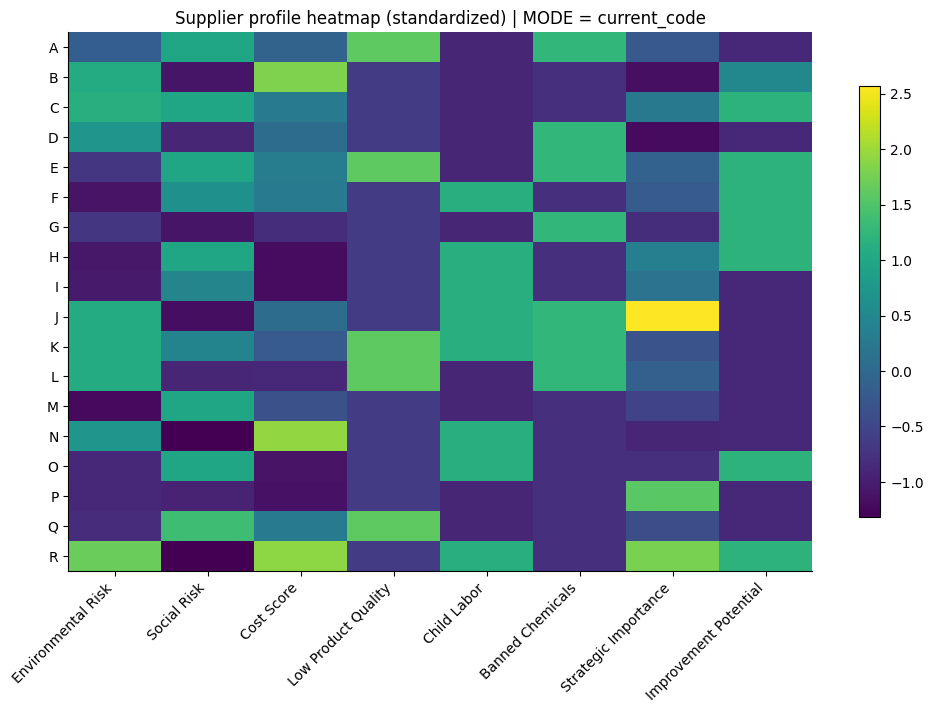

In [5]:

def zscore_frame(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    z = df[cols].astype(float).copy()
    for c in cols:
        std = z[c].std(ddof=0)
        if std == 0:
            z[c] = 0.0
        else:
            z[c] = (z[c] - z[c].mean()) / std
    return z

z = zscore_frame(supplier_t, PARETO_COLS)
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(z.to_numpy(), aspect="auto")
ax.set_xticks(range(len(PARETO_COLS)))
ax.set_xticklabels(PARETO_COLS, rotation=45, ha="right")
ax.set_yticks(range(len(supplier_t)))
ax.set_yticklabels(supplier_t["Supplier"])
ax.set_title(f"Supplier profile heatmap (standardized) | MODE = {MODE}")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.show()



## 3) Pareto dominance

Bir supplier `A`, `B`'yi domine eder eğer:

\[
A_k \ge B_k \ \forall k
\]

ve en az bir kriterde

\[
A_k > B_k
\]

olur.

Aşağıda pairwise dominance matrix ve özet tabloyu üretiyoruz.


In [6]:

def dominates(a: np.ndarray, b: np.ndarray, tol: float = 1e-12) -> bool:
    return np.all(a >= b - tol) and np.any(a > b + tol)

def pairwise_dominance_matrix(df: pd.DataFrame, item_col: str, cols: list[str]) -> pd.DataFrame:
    labels = df[item_col].tolist()
    X = df[cols].to_numpy(dtype=float)
    out = pd.DataFrame(False, index=labels, columns=labels)
    for i, li in enumerate(labels):
        for j, lj in enumerate(labels):
            if i == j:
                continue
            out.loc[li, lj] = dominates(X[i], X[j])
    return out

pareto_dom = pairwise_dominance_matrix(supplier_t, "Supplier", PARETO_COLS)

pareto_summary = pd.DataFrame({
    "dominates_count": pareto_dom.sum(axis=1).astype(int),
    "dominated_by_count": pareto_dom.sum(axis=0).astype(int),
}).sort_values(["dominated_by_count", "dominates_count"], ascending=[True, False])

pareto_frontier = pareto_summary.index[pareto_summary["dominated_by_count"] == 0].tolist()

display(pareto_summary)
print("Pareto frontier:", pareto_frontier)


,dominates_count,dominated_by_count
E,2,0
C,1,0
A,0,0
B,0,0
D,0,0
F,0,0
H,0,0
I,0,0
J,0,0
K,0,0


Pareto frontier: ['E', 'C', 'A', 'B', 'D', 'F', 'H', 'I', 'J', 'K', 'L', 'N', 'O', 'P', 'Q', 'R']


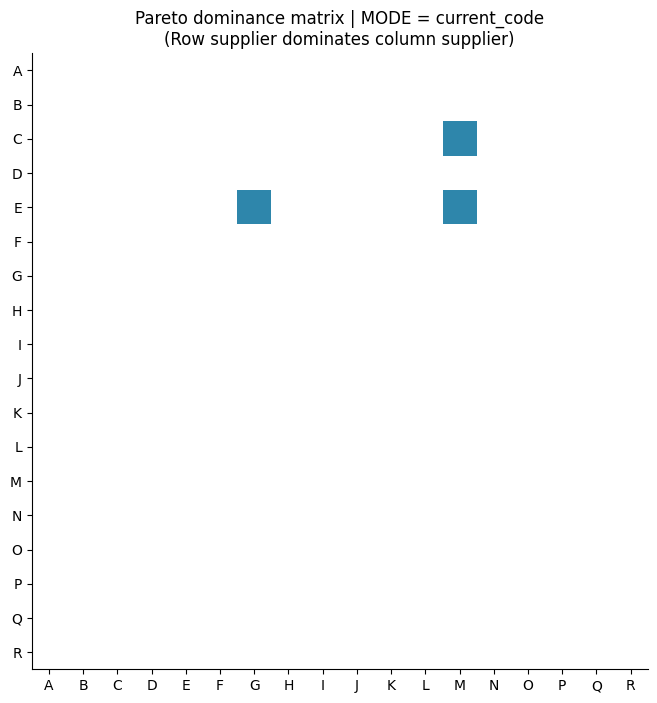

In [7]:

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(pareto_dom.astype(int).to_numpy(), cmap=ListedColormap(["white", "#2E86AB"]), aspect="equal")
ax.set_xticks(range(len(pareto_dom.columns)))
ax.set_xticklabels(pareto_dom.columns)
ax.set_yticks(range(len(pareto_dom.index)))
ax.set_yticklabels(pareto_dom.index)
ax.set_title(f"Pareto dominance matrix | MODE = {MODE}\n(Row supplier dominates column supplier)")
plt.show()


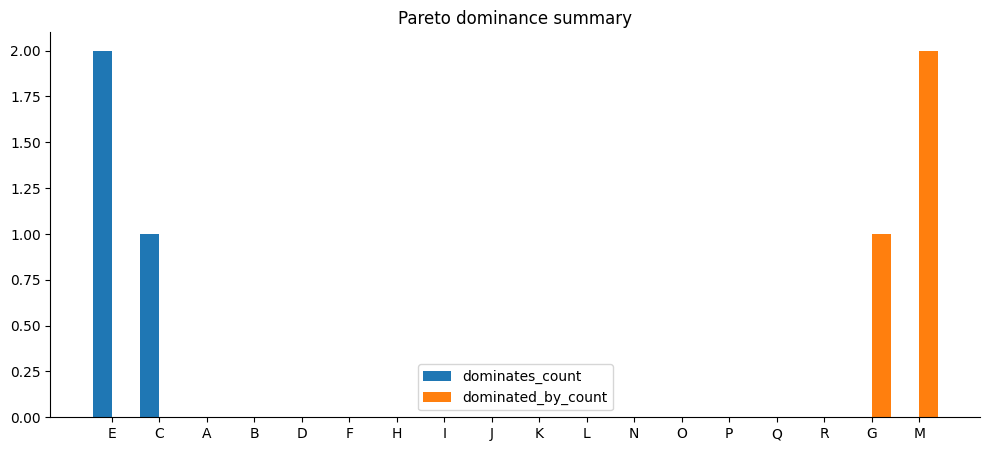

In [8]:

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(pareto_summary.index))
ax.bar(x - 0.2, pareto_summary["dominates_count"], width=0.4, label="dominates_count")
ax.bar(x + 0.2, pareto_summary["dominated_by_count"], width=0.4, label="dominated_by_count")
ax.set_xticks(x)
ax.set_xticklabels(pareto_summary.index)
ax.set_title("Pareto dominance summary")
ax.legend()
plt.show()



## 4) User ağırlıklarıyla utility matrisi

Bu bölümde her user ve her supplier için utility hesaplıyoruz.

\[
u_{user,supplier} = \sum_k w_{user,k} \cdot x_{supplier,k}
\]

Burada `x_{supplier,k}` dönüştürülmüş supplier skorlarıdır.


In [9]:

def build_utility_matrix(user_df: pd.DataFrame, supplier_transformed: pd.DataFrame) -> pd.DataFrame:
    supplier_lookup = supplier_transformed.set_index("Supplier")[UTILITY_COLS].astype(float)
    W = user_df[UTILITY_COLS].astype(float).to_numpy()
    U = pd.DataFrame(index=user_df["Users"].tolist(), columns=supplier_lookup.index.tolist(), dtype=float)
    for s in supplier_lookup.index:
        x = supplier_lookup.loc[s].to_numpy(dtype=float)
        U[s] = W @ x
    return U

U = build_utility_matrix(user_df, supplier_t)
display(U.head())
print(U.describe().T[["mean", "std", "min", "max"]].sort_values("mean", ascending=False).head(10))


,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R
1,3.023770,3.223789,3.421622,2.098913,3.521056,3.065437,1.779425,2.454680,1.933903,2.406685,2.848168,1.988253,2.498990,3.001456,2.388541,1.589264,3.296241,3.649332
2,1.884934,2.068220,2.516053,1.471240,2.235387,1.980559,1.488285,1.904841,1.473293,2.552363,1.989089,1.775316,1.459526,1.860553,1.628159,1.752338,1.842827,3.090908
3,2.051856,2.738888,2.538121,1.664210,2.588149,2.270148,1.561053,1.705853,1.255903,2.131424,2.034134,1.617772,1.587332,2.526890,1.608929,1.331265,2.180726,3.300121
4,1.862442,1.994403,2.321227,1.464905,2.105708,1.656128,1.293025,1.555469,1.164931,1.900444,2.075957,1.807417,1.243991,1.712496,1.498695,1.159579,1.788489,2.534066
5,3.482365,4.887857,4.361969,3.210567,3.913661,3.349562,2.341523,2.394350,1.993875,3.996604,3.792768,3.131844,2.503964,4.655833,2.314560,2.166969,3.519953,5.807635


       mean       std       min       max
R  3.849826  1.127863  1.864145  6.277120
C  3.323843  0.813558  1.616715  5.134043
B  3.131200  1.024848  1.414231  5.233811
E  3.131166  0.789530  1.598991  5.232122
N  2.812032  1.005316  1.208609  4.710922
F  2.757567  0.747025  1.361062  4.752947
Q  2.683373  0.704255  1.279183  4.395189
J  2.675768  0.703260  1.335195  4.411119
K  2.654851  0.623987  1.290578  4.068536
A  2.599461  0.630396  1.262350  4.059024


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27108\3043404562.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([U[c].to_numpy() for c in order], labels=order, showfliers=False)


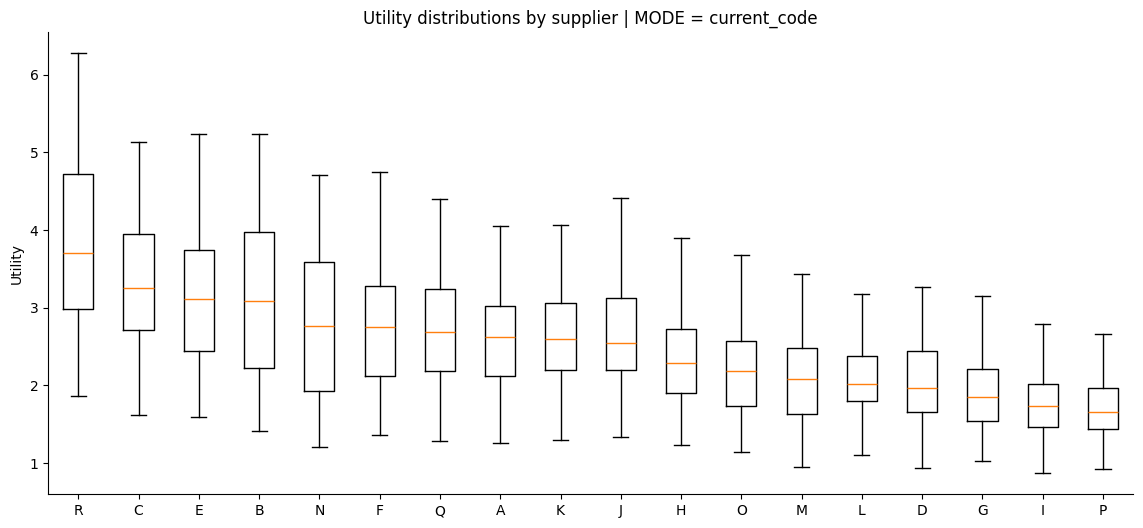

In [10]:

# Utility dağılımlarını mediana göre sırala
order = U.median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot([U[c].to_numpy() for c in order], labels=order, showfliers=False)
ax.set_title(f"Utility distributions by supplier | MODE = {MODE}")
ax.set_ylabel("Utility")
plt.xticks(rotation=0)
plt.show()



## 5) Pointwise utility dominance

Bir supplier `A`, `B`'yi utility bazında domine eder eğer **her user için**:

\[
u_{u,A} \ge u_{u,B}
\]

ve en az bir user için daha büyükse.


In [11]:

def pairwise_utility_dominance(U: pd.DataFrame, tol: float = 1e-12) -> pd.DataFrame:
    labels = U.columns.tolist()
    out = pd.DataFrame(False, index=labels, columns=labels)
    for a in labels:
        ua = U[a].to_numpy(dtype=float)
        for b in labels:
            if a == b:
                continue
            ub = U[b].to_numpy(dtype=float)
            out.loc[a, b] = np.all(ua >= ub - tol) and np.any(ua > ub + tol)
    return out

utility_dom = pairwise_utility_dominance(U)

utility_summary = pd.DataFrame({
    "utility_dominates_count": utility_dom.sum(axis=1).astype(int),
    "utility_dominated_by_count": utility_dom.sum(axis=0).astype(int),
    "utility_mean": U.mean(axis=0),
    "utility_median": U.median(axis=0),
}).sort_values(["utility_dominated_by_count", "utility_dominates_count", "utility_mean"],
               ascending=[True, False, False])

utility_frontier = utility_summary.index[utility_summary["utility_dominated_by_count"] == 0].tolist()

display(utility_summary)
print("Utility-undominated suppliers:", utility_frontier)


,utility_dominates_count,utility_dominated_by_count,utility_mean,utility_median
R,14,0,3.849826,3.707655
C,12,0,3.323843,3.253329
E,11,0,3.131166,3.112471
B,6,1,3.131200,3.084161
J,4,1,2.675768,2.552363
K,6,2,2.654851,2.592604
Q,2,2,2.683373,2.692408
N,1,2,2.812032,2.765150
F,5,3,2.757567,2.746729
A,4,3,2.599461,2.627732


Utility-undominated suppliers: ['R', 'C', 'E']


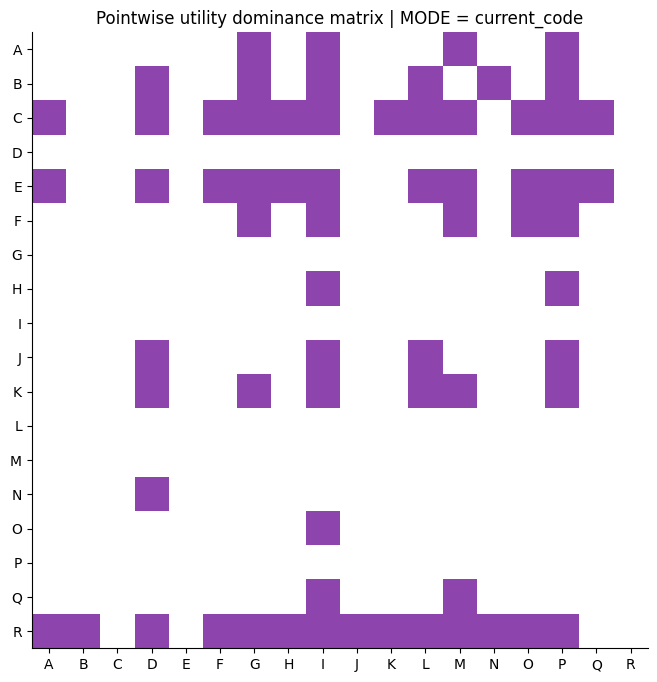

In [12]:

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(utility_dom.astype(int).to_numpy(), cmap=ListedColormap(["white", "#8E44AD"]), aspect="equal")
ax.set_xticks(range(len(utility_dom.columns)))
ax.set_xticklabels(utility_dom.columns)
ax.set_yticks(range(len(utility_dom.index)))
ax.set_yticklabels(utility_dom.index)
ax.set_title(f"Pointwise utility dominance matrix | MODE = {MODE}")
plt.show()



## 6) First-order stochastic dominance (FOSD)

A supplier `A`, supplier `B`'yi FOSD ile domine eder eğer utility dağılımının ampirik CDF'i her eşiğe göre daha aşağıda kalıyorsa:

\[
F_A(t) \le F_B(t) \ \forall t
\]

Sezgisel anlamı: `A`, her utility eşiğinde `B` kadar ya da daha iyi dağılım sunar.


In [13]:

def empirical_cdf(sample: np.ndarray, grid: np.ndarray) -> np.ndarray:
    sample = np.sort(np.asarray(sample, dtype=float))
    return np.searchsorted(sample, grid, side="right") / len(sample)

def fosd(sample_a: np.ndarray, sample_b: np.ndarray, tol: float = 1e-12) -> bool:
    grid = np.sort(np.unique(np.concatenate([sample_a, sample_b])))
    Fa = empirical_cdf(sample_a, grid)
    Fb = empirical_cdf(sample_b, grid)
    return np.all(Fa <= Fb + tol) and np.any(Fa < Fb - tol)

def pairwise_fosd(U: pd.DataFrame) -> pd.DataFrame:
    labels = U.columns.tolist()
    out = pd.DataFrame(False, index=labels, columns=labels)
    for a in labels:
        sa = U[a].to_numpy(dtype=float)
        for b in labels:
            if a == b:
                continue
            sb = U[b].to_numpy(dtype=float)
            out.loc[a, b] = fosd(sa, sb)
    return out

fosd_dom = pairwise_fosd(U)

fosd_summary = pd.DataFrame({
    "fosd_dominates_count": fosd_dom.sum(axis=1).astype(int),
    "fosd_dominated_by_count": fosd_dom.sum(axis=0).astype(int),
    "utility_mean": U.mean(axis=0),
}).sort_values(["fosd_dominated_by_count", "fosd_dominates_count", "utility_mean"],
               ascending=[True, False, False])

fosd_frontier = fosd_summary.index[fosd_summary["fosd_dominated_by_count"] == 0].tolist()

display(fosd_summary)
print("FOSD-undominated suppliers:", fosd_frontier)


,fosd_dominates_count,fosd_dominated_by_count,utility_mean
R,16,0,3.849826
C,14,0,3.323843
E,13,1,3.131166
B,9,1,3.131200
F,8,3,2.757567
Q,8,3,2.683373
J,8,3,2.675768
K,8,3,2.654851
A,8,3,2.599461
N,5,3,2.812032


FOSD-undominated suppliers: ['R', 'C']


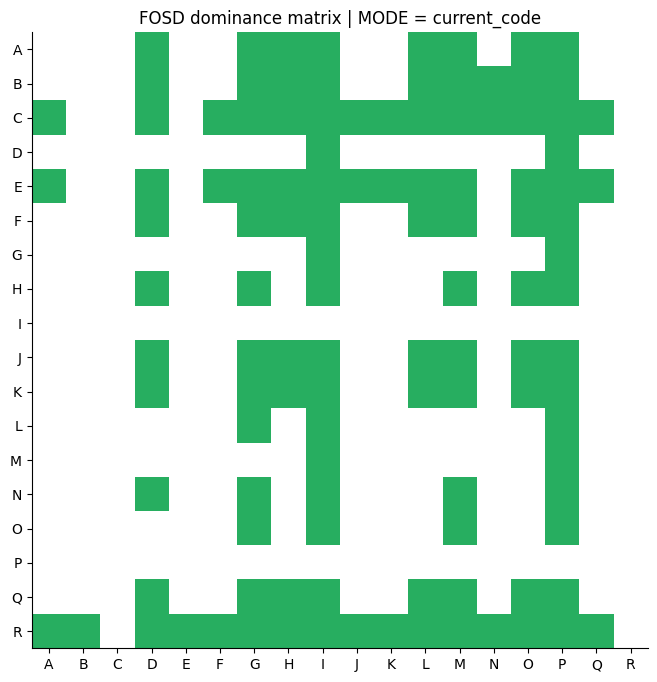

In [14]:

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(fosd_dom.astype(int).to_numpy(), cmap=ListedColormap(["white", "#27AE60"]), aspect="equal")
ax.set_xticks(range(len(fosd_dom.columns)))
ax.set_xticklabels(fosd_dom.columns)
ax.set_yticks(range(len(fosd_dom.index)))
ax.set_yticklabels(fosd_dom.index)
ax.set_title(f"FOSD dominance matrix | MODE = {MODE}")
plt.show()



## 7) Seçili supplier çiftleri için CDF karşılaştırması

Burada FOSD açısından en güçlü supplier'lardan birini seçip birkaç rakiple CDF'lerini kıyaslıyoruz.

Bir supplier'ın CDF eğrisi **diğerinin altında** kalıyorsa, utility dağılımı daha güçlüdür.


Anchor supplier: R
Comparison candidates: ['C', 'E', 'B']


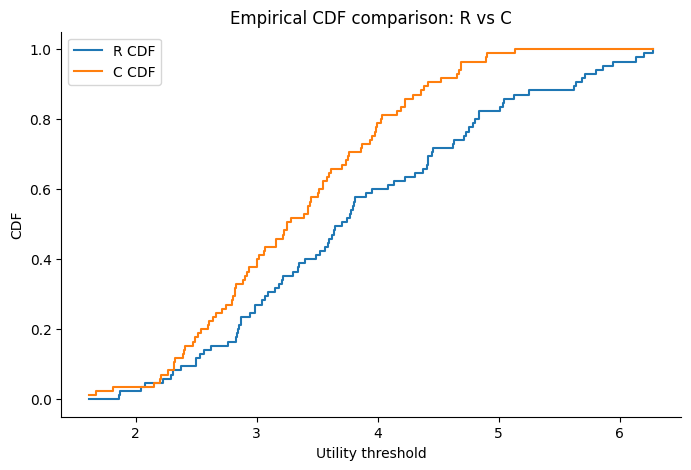

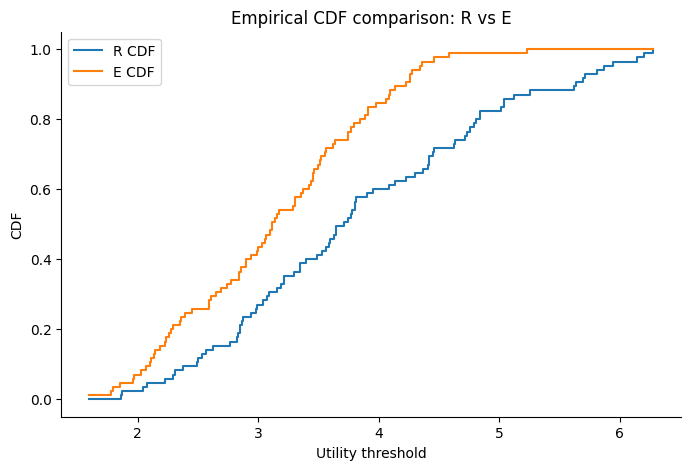

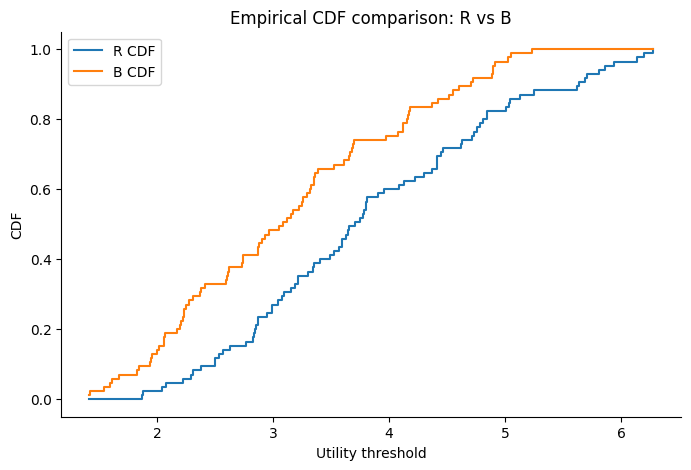

In [15]:

# En çok FOSD dominance yapan supplier'ı seç
anchor = fosd_summary["fosd_dominates_count"].idxmax()
comparison_candidates = fosd_summary.drop(index=anchor).head(3).index.tolist()

def plot_cdf_comparison(U: pd.DataFrame, a: str, b: str):
    sa = U[a].to_numpy(dtype=float)
    sb = U[b].to_numpy(dtype=float)
    grid = np.sort(np.unique(np.concatenate([sa, sb])))
    Fa = empirical_cdf(sa, grid)
    Fb = empirical_cdf(sb, grid)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.step(grid, Fa, where="post", label=f"{a} CDF")
    ax.step(grid, Fb, where="post", label=f"{b} CDF")
    ax.set_title(f"Empirical CDF comparison: {a} vs {b}")
    ax.set_xlabel("Utility threshold")
    ax.set_ylabel("CDF")
    ax.legend()
    plt.show()

print("Anchor supplier:", anchor)
print("Comparison candidates:", comparison_candidates)

for b in comparison_candidates:
    plot_cdf_comparison(U, anchor, b)



## 8) Tek tabloda özet

Bu tabloyu kullanarak:
- hangi supplier'ın kaç rakibi domine ettiğini,
- kaç supplier tarafından domine edildiğini,
- utility ve FOSD açısından frontier'da olup olmadığını

tek yerden görebilirsin.


In [16]:

summary = (
    pareto_summary
    .join(utility_summary[["utility_dominates_count", "utility_dominated_by_count", "utility_mean", "utility_median"]], how="outer")
    .join(fosd_summary[["fosd_dominates_count", "fosd_dominated_by_count"]], how="outer")
)

summary["pareto_undominated"] = summary["dominated_by_count"] == 0
summary["utility_undominated"] = summary["utility_dominated_by_count"] == 0
summary["fosd_undominated"] = summary["fosd_dominated_by_count"] == 0

summary = summary.sort_values(
    ["fosd_undominated", "utility_undominated", "pareto_undominated", "utility_mean"],
    ascending=[False, False, False, False]
)

display(summary)


,dominates_count,dominated_by_count,utility_dominates_count,utility_dominated_by_count,utility_mean,utility_median,fosd_dominates_count,fosd_dominated_by_count,pareto_undominated,utility_undominated,fosd_undominated
R,0,0,14,0,3.849826,3.707655,16,0,True,True,True
C,1,0,12,0,3.323843,3.253329,14,0,True,True,True
E,2,0,11,0,3.131166,3.112471,13,1,True,True,False
B,0,0,6,1,3.131200,3.084161,9,1,True,False,False
N,0,0,1,2,2.812032,2.765150,5,3,True,False,False
F,0,0,5,3,2.757567,2.746729,8,3,True,False,False
Q,0,0,2,2,2.683373,2.692408,8,3,True,False,False
J,0,0,4,1,2.675768,2.552363,8,3,True,False,False
K,0,0,6,2,2.654851,2.592604,8,3,True,False,False
A,0,0,4,3,2.599461,2.627732,8,3,True,False,False
